In [6]:
import xarray as xr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans
import cartopy.io.shapereader as shpreader
from shapely import contains_xy


# Config

In [7]:
data_dir = "data/ENACTS"
start_year = 2000
end_year = 2022
var_name = "precip"

# Data

In [29]:

years = list(range(int(start_year), int(end_year) + 1))
files = [Path(data_dir) / f"{y}.nc" for y in years]

existing_files = [str(f) for f in files if f.exists()]
print(f'Found **{len(existing_files)}** files')

ds = xr.open_mfdataset(
    existing_files,
    combine="by_coords",
    parallel=True,
    engine="netcdf4",
    chunks={"time": 365},
)
print(ds.dims)

rename_map = {}
for old, new in [
    ("LATITUDE", "latitude"),
    ("LONGITUDE", "longitude"),
    ("lat", "latitude"),
    ("lon", "longitude"),
]:
    if old in ds.dims or old in ds.coords:
        rename_map[old] = new
if rename_map:
    ds = ds.rename(rename_map)

da = ds[var_name]


Found **23** files
FrozenMappingWarningOnValuesAccess({'time': 5501, 'lat': 49, 'lon': 61})


# Clustering

### 1. Weekly climatology

In [30]:
weekly_total = da.resample(time="7D").sum(skipna=False)
week = weekly_total.time.dt.strftime("%V").astype(int)
weekly_total = weekly_total.assign_coords(week=("time", week.data))
weekly_clim = weekly_total.groupby("week").mean("time")

# Keep weeks ordered
weekly_clim = weekly_clim.sortby("week")

X_weekly = weekly_clim.transpose("latitude", "longitude", "week").values
n_lat, n_lon, n_week = X_weekly.shape

annual_total = np.nansum(X_weekly, axis=2)

weeks = weekly_clim["week"].values

# Focus on onset window
onset_window = (weeks >= 15) & (weeks <= 46)
weeks_onset = weeks[onset_window]


### Cutting out insignificant rainfall

This mask filters out any regions that do not have significant share of rainfall during the selected season. 

In [13]:
# You can adjust the weeks here to evaluate a different season
season_weeks = (weeks >= 22) & (weeks <= 36)

rain_season = np.nansum(X_weekly[:, :, season_weeks], axis=2)
frac_season = rain_season / annual_total

keep_mask_2d = frac_season >= 0.10


/var/folders/w4/c7srzhyx44v_rr22dd7ncd480000gn/T/ipykernel_1248/742735658.py:5: RuntimeWarning: invalid value encountered in divide
  frac_season = rain_season / annual_total


This mask cuts out any points outside of the Ethiopia boundary.

In [31]:

shp = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_0_countries",
)

ethiopia_geom = None
for rec in shpreader.Reader(shp).records():
    if rec.attributes["NAME"] == "Ethiopia":
        ethiopia_geom = rec.geometry
        break

if ethiopia_geom is None:
    raise RuntimeError("Could not find Ethiopia geometry.")

lon = weekly_clim["longitude"].values
lat = weekly_clim["latitude"].values
lon2d, lat2d = np.meshgrid(lon, lat)

ethiopia_mask_2d = contains_xy(
    ethiopia_geom,
    lon2d.ravel(),
    lat2d.ravel()
).reshape(lat.size, lon.size)

### Apply masks and scale rainfall values

In [32]:
weekly_onset = X_weekly[:, :, onset_window]
X_flat = weekly_onset.reshape(-1, weekly_onset.shape[2])

keep_mask_flat = keep_mask_2d.reshape(-1)
valid_mask = np.isfinite(X_flat).all(axis=1) & keep_mask_flat & ethiopia_mask_2d.reshape(-1)
X_valid = X_flat[valid_mask]

mu = X_valid.mean(axis=1, keepdims=True)
sd = X_valid.std(axis=1, keepdims=True)
X_scaled = (X_valid - mu) / sd

# X_valid or X_scaled
X_for_k = X_scaled

### Elbow-curve Heuristic
For K-means clustering it's common to use a hueristic to pick a good K value (the number of clusters). The elbow-curve is a good hueristic because it shows the imrpovement you get from adding another cluster. Specifically, it shows how the within cluster sum of squares (i.e. how spread out each cluster is) is reduced for each additional cluster center added. However, what threshold to use depends on what you expect from the clustering. Ultimately, choosing a good K depends a lot on domain knowledge.

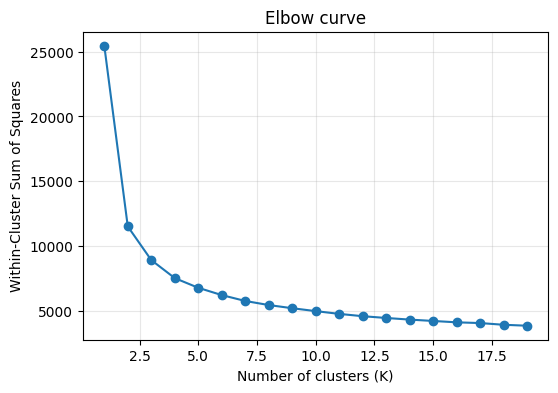

In [33]:

K_values = range(1, 20)
inertia = []

for k in K_values:
    model = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )
    model.fit(X_for_k)
    inertia.append(model.inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_values), inertia, marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Within-Cluster Sum of Squares")
ax.set_title("Elbow curve")
ax.grid(alpha=0.3)
plt.show()


### Clustering with selected K

In [35]:
K = 5
model = KMeans(n_clusters=K, random_state=0, n_init=10)
labels = model.fit_predict(X_for_k)

# Map labels back to grid
label_grid_flat = np.full(n_lat * n_lon, np.nan)
label_grid_flat[valid_mask] = labels
label_grid = label_grid_flat.reshape(n_lat, n_lon)


cluster_ids = np.unique(labels)
centroids = np.zeros((len(cluster_ids), len(weeks_onset)))
for i, cid in enumerate(cluster_ids):
    centroids[i] = X_for_k[labels == cid].mean(axis=0)

# Shared colors
cmap = plt.get_cmap("tab10", len(cluster_ids))
norm = mpl.colors.BoundaryNorm(np.arange(-0.5, len(cluster_ids) + 0.5, 1), cmap.N)

lat = weekly_clim["latitude"].values
lon = weekly_clim["longitude"].values

### Plotting clusters

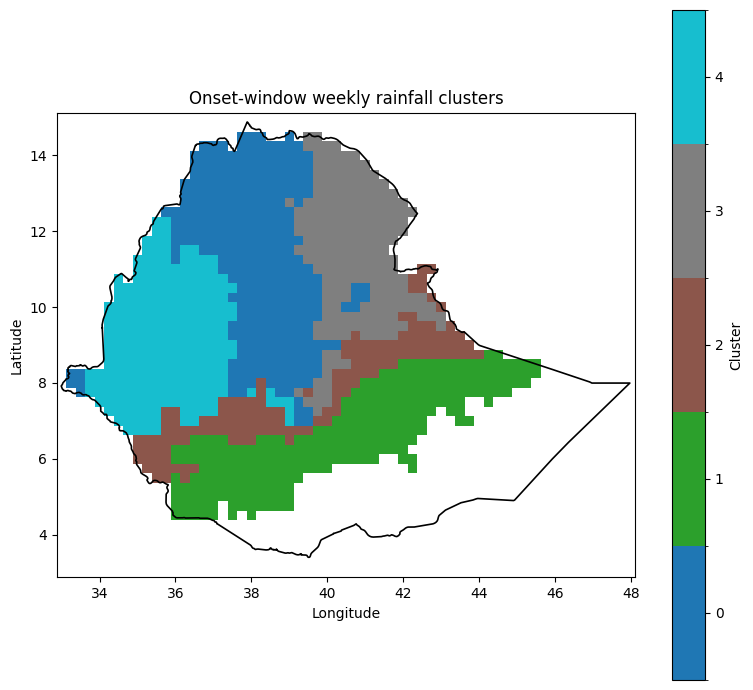

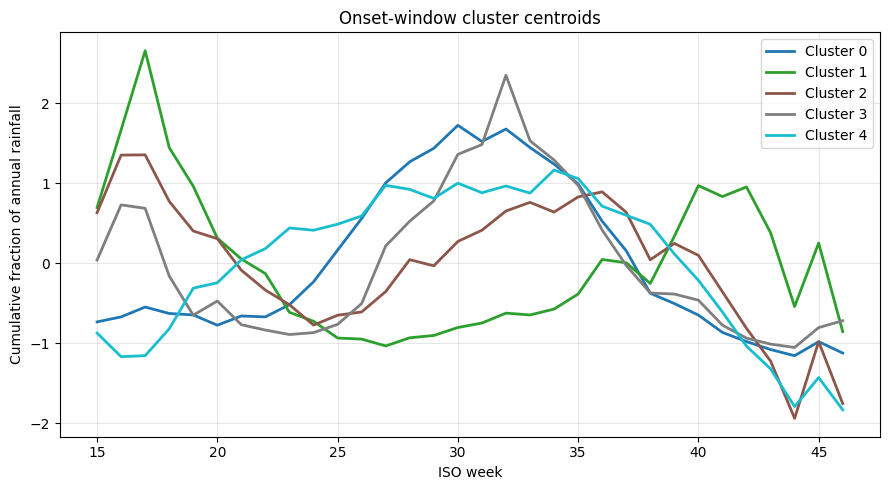

In [36]:
geoms = ethiopia_geom.geoms if hasattr(ethiopia_geom, "geoms") else [ethiopia_geom]

# Plot cluster map
fig, ax = plt.subplots(figsize=(8, 7))
mesh = ax.pcolormesh(lon, lat, label_grid, shading="auto", cmap=cmap, norm=norm)
cbar = fig.colorbar(mesh, ax=ax, ticks=np.arange(len(cluster_ids)))
cbar.set_label("Cluster")
for g in geoms:
    x, y = g.exterior.xy
    ax.plot(x, y, color="black", linewidth=1.2)
ax.set_title("Onset-window weekly rainfall clusters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

# Plot centroid curves
fig, ax = plt.subplots(figsize=(9, 5))
for i, cid in enumerate(cluster_ids):
    ax.plot(
        weeks_onset,
        centroids[i],
        color=cmap(i),
        linewidth=2,
        label=f"Cluster {cid}"
    )
ax.set_xlabel("ISO week")
ax.set_ylabel("Cumulative fraction of annual rainfall")
ax.set_title("Onset-window cluster centroids")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



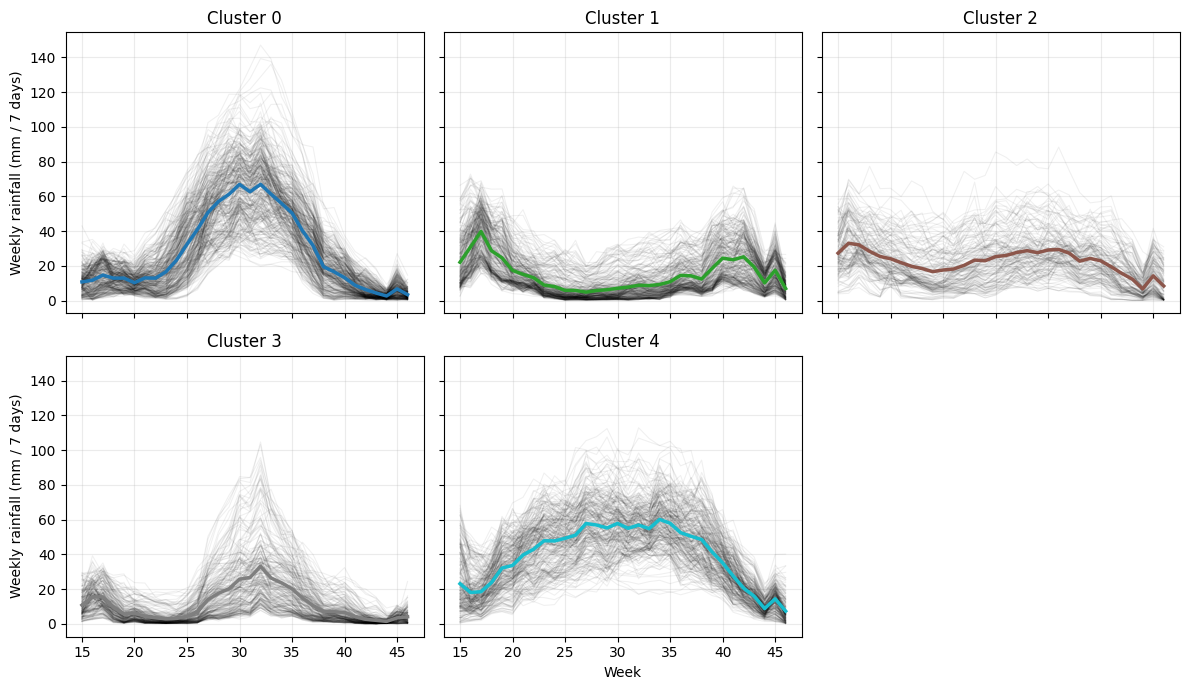

In [23]:

# Build raw centroids (calculate the mean rainfall for each week for each centroids)
centroids_raw = np.zeros((K, X_valid.shape[1]))
for i, cid in enumerate(cluster_ids):
    centroids_raw[i] = X_valid[labels == cid].mean(axis=0)

ncols = 3
nrows = int(np.ceil(K / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows), sharex=True, sharey=True)
axes = axes.ravel()

for i, cid in enumerate(cluster_ids):
    ax = axes[i]
    color = cmap(i)
    members = X_valid[labels == cid]

    for row in members:
        ax.plot(weeks_onset, row, color="black", alpha=0.06, linewidth=0.8)

    ax.plot(weeks_onset, centroids_raw[i], color=color, linewidth=2.5)
    ax.set_title(f"Cluster {cid}")
    ax.grid(alpha=0.25)

for j in range(len(cluster_ids), len(axes)):
    axes[j].set_visible(False)
    
ax.set_xlabel("Week")

for idx in range(0, len(axes), ncols):
    axes[idx].set_ylabel("Weekly rainfall (mm / 7 days)")

plt.tight_layout()
plt.show()



## Guide
### Change number of clusters
Go to heading "Clustering with selected K" and change the value of the variable K. Then run all cells below.
### Switch to un-scaled values for clustering
By default the values used for clustering are z-scores. This means that points that are similarly close/far from their individual mean rainfall across weeks will be clustered together. If you would like to cluster based on raw values you can switch this at the bottom of the cell under "Apply masks and scale rainfall values."
### Changing the season
Look under the "weekly climatology" heading.